In [10]:
!pip install wfdb --quiet

import os, ast, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import wfdb

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [11]:
BASE = "/kaggle/input/ecg-detection/ptbl_xl_large_dataset"

DB_CSV  = os.path.join(BASE, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE, "scp_statements.csv")

db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)

mi_codes = []

for c in scp["Unnamed: 0"].astype(str):
    u = c.upper()
    if any(k in u for k in [
        "MI","IMI","AMI","INFARCTION",
        "STEMI","NSTEMI","INFERIOR MI","ANTERIOR MI","POSTERIOR MI",
        "OLD MI","OMI","PMI","LMI"
    ]):
        mi_codes.append(c)

mi_codes = set(mi_codes)
print("MI/CAD codes detected:", len(mi_codes))


MI/CAD codes detected: 9


In [12]:
def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

def map_label_2class(s):
    if "NORM" in s:
        return 0
    if len(s & mi_codes) > 0:
        return 1
    return None

db["label_2"] = db["scp_set"].apply(map_label_2class)

db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Class distribution:", db2["label_2"].value_counts())


Class distribution: label_2
0    9514
1    5287
Name: count, dtype: int64


In [13]:
def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

def map_label_2class(s):
    if "NORM" in s:
        return 0
    if len(s & mi_codes) > 0:
        return 1
    return None

db["label_2"] = db["scp_set"].apply(map_label_2class)

db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Class distribution:", db2["label_2"].value_counts())


Class distribution: label_2
0    9514
1    5287
Name: count, dtype: int64


In [25]:
target_n = 5286     # or 9514 (if GPU strong hai)

idx_0 = db2[db2["label_2"]==0].sample(target_n, random_state=SEED).index
idx_1 = db2[db2["label_2"]==1].sample(target_n, random_state=SEED).index

db_bal = db2.loc[idx_0.union(idx_1)].sample(frac=1, random_state=SEED)

print("Balanced:", db_bal["label_2"].value_counts())


Balanced: label_2
0    5286
1    5286
Name: count, dtype: int64


In [15]:
from scipy.signal import butter, filtfilt, resample

TARGET_FS = 500
TARGET_LEN = 5000
NUM_LEADS = 12

def butter_bandpass(low, high, fs, order=4):
    nyq = fs * 0.5
    return butter(order, [low/nyq, high/nyq], btype="band")

def clean_ecg(sig, fs):
    sig = np.nan_to_num(sig)

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])))
    else:
        sig = sig[:, :12]

    b,a = butter_bandpass(0.5,40,fs)

    cleaned = []
    for i in range(12):
        cleaned.append(filtfilt(b,a,sig[:,i]))
    cleaned = np.stack(cleaned,axis=1)

    new_len = int(cleaned.shape[0] * TARGET_FS / fs)
    cleaned = np.stack([resample(cleaned[:,i], new_len) for i in range(12)],axis=1)

    if cleaned.shape[0] > TARGET_LEN:
        start = (cleaned.shape[0]-TARGET_LEN)//2
        cleaned = cleaned[start:start+TARGET_LEN]
    else:
        pad = TARGET_LEN-cleaned.shape[0]
        cleaned = np.pad(cleaned,((pad//2,pad-pad//2),(0,0)))

    for i in range(12):
        std = cleaned[:,i].std()
        if std < 1e-6: return None
        cleaned[:,i]=(cleaned[:,i]-cleaned[:,i].mean())/(std+1e-8)

    return cleaned.astype(np.float32)


In [16]:
X_list = []
y_list = []

for _, row in tqdm(db_bal.iterrows(), total=len(db_bal)):
    fpath = os.path.join(BASE, row["filename_hr"]) if isinstance(row["filename_hr"], str) else os.path.join(BASE, row["filename"])

    try:
        rec = wfdb.rdrecord(fpath)
        sig = rec.p_signal
        fs  = rec.fs
    except:
        continue
    
    clean = clean_ecg(sig, fs)
    if clean is None:
        continue

    X_list.append(clean)
    y_list.append(row["label_2"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("Final X:", X.shape)
print("Final y:", Counter(y))


100%|██████████| 10572/10572 [02:26<00:00, 72.33it/s]


Final X: (10571, 5000, 12)
Final y: Counter({0: 5286, 1: 5285})


In [17]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (8086, 5000, 12)
Val: (899, 5000, 12)
Test: (1586, 5000, 12)


In [18]:
# ---------------- Squeeze-Excitation ----------------
def SE_block(x, reduction=4):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])

# ---------------- MBConv Block -----------------------
def MBConv1D(x, filters, expand_ratio=4, stride=1, reduction=4):
    inp = x
    in_ch = x.shape[-1]
    exp_ch = int(in_ch * expand_ratio)

    x = layers.Conv1D(exp_ch, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.DepthwiseConv1D(3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = SE_block(x, reduction)

    x = layers.Conv1D(filters, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride == 1 and in_ch == filters:
        x = layers.Add()([x, inp])

    return x

# ---------------- EfficientNet-1D Model -----------------------
def build_efficientnet1d(input_shape=(5000, 12)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 3, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = MBConv1D(x, 16, expand_ratio=1, stride=1)

    x = MBConv1D(x, 24, expand_ratio=6, stride=2)
    x = MBConv1D(x, 24, expand_ratio=6, stride=1)

    x = MBConv1D(x, 40, expand_ratio=6, stride=2)
    x = MBConv1D(x, 40, expand_ratio=6, stride=1)

    x = MBConv1D(x, 80, expand_ratio=6, stride=2)
    x = MBConv1D(x, 80, expand_ratio=6, stride=1)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inp, out, name="EfficientNet1D")

model = build_efficientnet1d((X.shape[1], X.shape[2]))
model.summary()


Model: "EfficientNet1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2500, 32)  │      1,184 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 32)  │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2500, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2500, 32)  │      1,024 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 32)  │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2500, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d    │ (None, 2500, 32)  │         96 │ activation_2[0][… │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 32)  │        128 │ depthwise_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2500, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2500, 32)  │          0 │ activation_3[0][… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2500, 16)  │        512 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 16)  │         64 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2500, 96)  │      1,536 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 96)  │        384 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 374,841 (1.43 MB)

 Trainable params: 368,665 (1.41 MB)

 Non-trainable params: 6,176 (24.12 KB)

In [26]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
cw = {int(c): float(w) for c, w in zip(classes, cw)}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ckpt_path = "/kaggle/working/effnet1d_best.h5"

cbs = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=32,
    class_weight=cw,
    callbacks=cbs,
    verbose=1
)


Epoch 1/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9286 - loss: 0.1813

253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - accuracy: 0.9286 - loss: 0.1813 - val_accuracy: 0.8999 - val_loss: 0.2599 - learning_rate: 1.0000e-04
Epoch 2/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9410 - loss: 0.1508 - val_accuracy: 0.8810 - val_loss: 0.2978 - learning_rate: 1.0000e-04
Epoch 3/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9569 - loss: 0.1206 - val_accuracy: 0.8776 - val_loss: 0.3290 - learning_rate: 1.0000e-04
Epoch 4/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9685 - loss: 0.0940 - val_accuracy: 0.8621 - val_loss: 0.4262 - learning_rate: 1.0000e-04
Epoch 5/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9841 - loss: 0.0625 - val_accuracy: 0.8854 - val_loss: 0.4124 - learning_rate: 5.0000e-05
Epoch 6/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9913 - loss: 0.0407 - val_accuracy: 0.8877 - val_loss: 0.4612 - learning_rate: 5.0000e-05
Epoch 7/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9053 - loss: 0.2638
Test Accuracy: 0.8991172909736633
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       793
           1       0.90      0.89      0.90       793

    accuracy                           0.90      1586
   macro avg       0.90      0.90      0.90      1586
weighted avg       0.90      0.90      0.90      1586



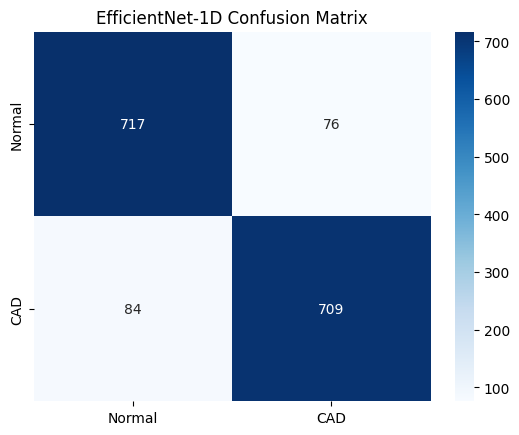

In [27]:
model.load_weights(ckpt_path)

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal","CAD"],
    yticklabels=["Normal","CAD"]
)
plt.title("EfficientNet-1D Confusion Matrix")
plt.show()
